# Generator–Evaluator Image Workflow with LangGraph

This notebook uses Gemini to generate an image from a reference and to count a requested item in the result. LangGraph compares that count with the expected count and retries generation up to three times. Every attempt—including generation errors—is retained in the final state and displayed at the end.

## 1. Sync project dependencies

This repository uses `uv`. Run this cell, then select the project's `.venv` as the notebook kernel if imports are unavailable.

In [48]:
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent

assert (project_root / "pyproject.toml").exists(), (
    "Run this notebook from the project root or notebooks folder."
)

!UV_CACHE_DIR="{project_root / '.uv-cache'}" uv sync --project "{project_root}"

print(f"Project environment: {project_root / '.venv'}")
print("If imports fail, switch this notebook to the .venv kernel and rerun the cells.")

Resolved 78 packages in 25ms
Checked 75 packages in 20ms
Project environment: /Users/aman/Work/ai/guide/.venv
If imports fail, switch this notebook to the .venv kernel and rerun the cells.


## 2. Configure the Gemini API key

The key is read from `GEMINI_API_KEY` when available. Otherwise, the notebook prompts for it securely without displaying the value.

In [49]:
import getpass
import os

if not os.environ.get("GEMINI_API_KEY"):
    api_key = getpass.getpass("Enter your Gemini API key: ").strip()
    if not api_key:
        raise ValueError("A Gemini API key is required.")
    os.environ["GEMINI_API_KEY"] = api_key

## 3. Set the workflow inputs

The generation prompt should state the desired item count explicitly. Success is determined only by whether Gemini's detected count matches `expected_item_count`.

In [50]:
user_image_url = "https://randomuser.me/api/portraits/women/8.jpg"

generation_prompt = """
Image requirement:
highly detailed illustrated tarot card, soft storybook illustration style, hand-painted look, pastel color palette, spring floral environment,
delicate textures, smooth shading, whimsical magical atmosphere

ornate decorative tarot frame, elegant gold floral border, intricate linework, symmetrical art nouveau design

soft glowing particles, dreamy lighting, painterly rendering

same person as reference image, identical face, preserve facial features exactly, same eyes, nose, lips, natural skin texture, clean skin

adapt clothing, styling, and presence to match the person naturally (do not force gender-specific outfits unless defined in the scene)

center composition, tarot card layout

top title area with elegant serif tarot typography, Roman numeral above the title, same position, same font style, same size, same spacing
across all cards, only change the title text according to the card name

clean balanced margins, no distortion of frame

create a scene, pose, and environment based on the tarot card meaning, while keeping the same illustration style, frame, and character identity

ensure variation in pose, camera angle, and composition for each card while maintaining overall style consistency

Your task is to generate the following card:-
TITLE: NINE OF WANDS
 ROMAN NUMERAL: IX
 Person standing in guard.
 There should be exactly 9 wands in the output image.
""".strip()

expected_item_name = "wand"
expected_item_count = 9

## 4. Download and preview the reference image

The reference image is validated once before the graph runs. A download failure therefore does not consume a generation attempt.

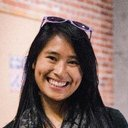

In [51]:
from dataclasses import dataclass
from urllib.error import HTTPError, URLError
from urllib.request import Request, urlopen

from IPython.display import Image as DisplayImage
from IPython.display import display


@dataclass(frozen=True)
class DownloadedImage:
    data: bytes
    mime_type: str


def download_image(url: str, timeout: float = 30.0) -> DownloadedImage:
    if not url.lower().startswith(("http://", "https://")):
        raise ValueError(f"Image URL must use http or https: {url!r}")

    request = Request(url, headers={"User-Agent": "image-generator-evaluator-notebook/1.0"})
    try:
        with urlopen(request, timeout=timeout) as response:
            mime_type = response.headers.get_content_type().lower()
            if not mime_type.startswith("image/"):
                raise ValueError(
                    f"URL did not return an image (Content-Type: {mime_type!r}): {url}"
                )
            data = response.read()
    except HTTPError as exc:
        raise RuntimeError(f"Image request failed with HTTP {exc.code}: {url}") from exc
    except URLError as exc:
        raise RuntimeError(f"Could not download image from {url}: {exc.reason}") from exc

    if not data:
        raise ValueError(f"Image response was empty: {url}")

    return DownloadedImage(data=data, mime_type=mime_type)


reference_image = download_image(user_image_url)
display(DisplayImage(data=reference_image.data, width=300))

## 5. Define graph state and structured model responses

In [52]:
import base64
from typing import Literal, TypedDict

from google import genai
from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, Field

GENERATION_MODEL = "gemini-3.1-flash-image-preview"
VISION_MODEL = "gemini-3.8-flash"
MAX_ATTEMPTS = 3
ASPECT_RATIO = "9:16"

client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])


class ItemCountResponse(BaseModel):
    count: int = Field(ge=0)
    feedback: str


class AttemptRecord(TypedDict):
    attempt_number: int
    generation_status: Literal["success", "error"]
    generated_image_data: str | None
    generated_image_mime_type: str | None
    generation_interaction_id: str | None
    generation_error: str | None
    count_status: Literal["pending", "success", "error", "skipped"]
    detected_item_count: int | None
    count_feedback: str | None
    count_error: str | None


class ImageGeneratorEvaluatorState(TypedDict):
    user_image_url: str
    reference_image_data: bytes
    reference_image_mime_type: str
    generation_prompt: str
    expected_item_name: str
    expected_item_count: int
    current_attempt: int
    attempts: list[AttemptRecord]
    result: Literal["running", "success", "max_attempts_reached"]

## 6. Define the graph nodes

`generate_image` increments the attempt counter before making the API call, so runtime failures consume an attempt. Counting failures trigger a new generation when attempts remain. `evaluate_image` makes no model call; it only compares the detected and expected counts.

In [53]:
def _new_attempt(attempt_number: int) -> AttemptRecord:
    return {
        "attempt_number": attempt_number,
        "generation_status": "error",
        "generated_image_data": None,
        "generated_image_mime_type": None,
        "generation_interaction_id": None,
        "generation_error": None,
        "count_status": "pending",
        "detected_item_count": None,
        "count_feedback": None,
        "count_error": None,
    }


def _replace_latest_attempt(
    attempts: list[AttemptRecord], latest: AttemptRecord
) -> list[AttemptRecord]:
    return [*attempts[:-1], latest]


def generate_image(state: ImageGeneratorEvaluatorState) -> dict:
    attempt_number = state["current_attempt"] + 1
    attempt = _new_attempt(attempt_number)

    try:
        interaction = client.interactions.create(
            model=GENERATION_MODEL,
            input=[
                {"type": "text", "text": state["generation_prompt"]},
                {
                    "type": "image",
                    "data": base64.b64encode(
                        state["reference_image_data"]
                    ).decode("ascii"),
                    "mime_type": state["reference_image_mime_type"],
                },
            ],
            response_format={
                "type": "image",
                "aspect_ratio": ASPECT_RATIO,
                "mime_type": "image/jpeg",
            },
        )

        if interaction.output_image is None or not interaction.output_image.data:
            detail = interaction.output_text or "No explanatory text was returned."
            raise RuntimeError(f"Gemini did not return an image. {detail}")

        encoded_image = interaction.output_image.data
        base64.b64decode(encoded_image, validate=True)
        attempt.update(
            generation_status="success",
            generated_image_data=encoded_image,
            generated_image_mime_type=interaction.output_image.mime_type,
            generation_interaction_id=getattr(interaction, "id", None),
        )
    except Exception as exc:
        attempt["generation_error"] = f"{type(exc).__name__}: {exc}"

    return {
        "current_attempt": attempt_number,
        "attempts": [*state["attempts"], attempt],
        "result": "running",
    }


def count_items_in_generated_image(state: ImageGeneratorEvaluatorState) -> dict:
    attempt = dict(state["attempts"][-1])
    if attempt["generation_status"] != "success":
        attempt["count_status"] = "skipped"
        return {"attempts": _replace_latest_attempt(state["attempts"], attempt)}

    try:
        count_prompt = (
            f"Count the actual visible instances of {state['expected_item_name']!r} "
            "in this image. Ignore written numbers, labels, titles, symbols, and any "
            "number stated in the prompt. Count only the depicted physical items. "
            "Briefly explain what you counted."
        )
        interaction = client.interactions.create(
            model=VISION_MODEL,
            input=[
                {"type": "text", "text": count_prompt},
                {
                    "type": "image",
                    "data": attempt["generated_image_data"],
                    "mime_type": attempt["generated_image_mime_type"],
                },
            ],
            response_format={
                "type": "text",
                "mime_type": "application/json",
                "schema": ItemCountResponse.model_json_schema(),
            },
        )
        parsed = ItemCountResponse.model_validate_json(interaction.output_text)
        attempt.update(
            count_status="success",
            detected_item_count=parsed.count,
            count_feedback=parsed.feedback,
        )
    except Exception as exc:
        attempt.update(
            count_status="error",
            count_error=f"{type(exc).__name__}: {exc}",
        )

    return {"attempts": _replace_latest_attempt(state["attempts"], attempt)}


def evaluate_image(state: ImageGeneratorEvaluatorState) -> dict:
    attempt = state["attempts"][-1]

    count_matches = (
        attempt["count_status"] == "success"
        and attempt["detected_item_count"] == state["expected_item_count"]
    )
    if count_matches:
        result = "success"
    elif state["current_attempt"] >= MAX_ATTEMPTS:
        result = "max_attempts_reached"
    else:
        result = "running"

    return {"result": result}

## 7. Build and inspect the graph

In [54]:
def route_after_evaluation(
    state: ImageGeneratorEvaluatorState,
) -> Literal["retry", "end"]:
    return "retry" if state["result"] == "running" else "end"


builder = StateGraph(ImageGeneratorEvaluatorState)
builder.add_node("generate_image", generate_image)
builder.add_node("count_items_in_generated_image", count_items_in_generated_image)
builder.add_node("evaluate_image", evaluate_image)

builder.add_edge(START, "generate_image")
builder.add_edge("generate_image", "count_items_in_generated_image")
builder.add_edge("count_items_in_generated_image", "evaluate_image")
builder.add_conditional_edges(
    "evaluate_image",
    route_after_evaluation,
    {"retry": "generate_image", "end": END},
)

graph = builder.compile()

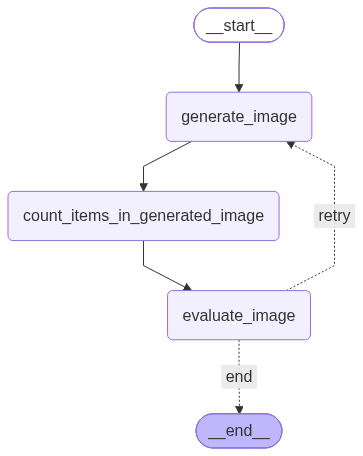

In [55]:
display(DisplayImage(graph.get_graph().draw_mermaid_png()))

## 8. Validate inputs and run the workflow

In [56]:
def validate_inputs() -> None:
    text_inputs = {
        "user_image_url": user_image_url,
        "generation_prompt": generation_prompt,
        "expected_item_name": expected_item_name,
    }
    for name, value in text_inputs.items():
        if not isinstance(value, str) or not value.strip():
            raise ValueError(f"{name} must be a non-empty string.")

    if isinstance(expected_item_count, bool) or not isinstance(expected_item_count, int):
        raise TypeError("expected_item_count must be an integer.")
    if expected_item_count < 0:
        raise ValueError("expected_item_count must be non-negative.")


validate_inputs()

initial_state: ImageGeneratorEvaluatorState = {
    "user_image_url": user_image_url,
    "reference_image_data": reference_image.data,
    "reference_image_mime_type": reference_image.mime_type,
    "generation_prompt": generation_prompt,
    "expected_item_name": expected_item_name,
    "expected_item_count": expected_item_count,
    "current_attempt": 0,
    "attempts": [],
    "result": "running",
}

final_state = graph.invoke(initial_state)

## 9. Display every attempt

The full structured history remains available in `final_state["attempts"]`.


Attempt 1
Generation: success
Interaction ID: v1_Chc2c3F2YXVxOEJMN2ZnOFVQajZtdHFBVRIXNnNxdmF1cThCTDdmZzhVUGo2bXRxQVU


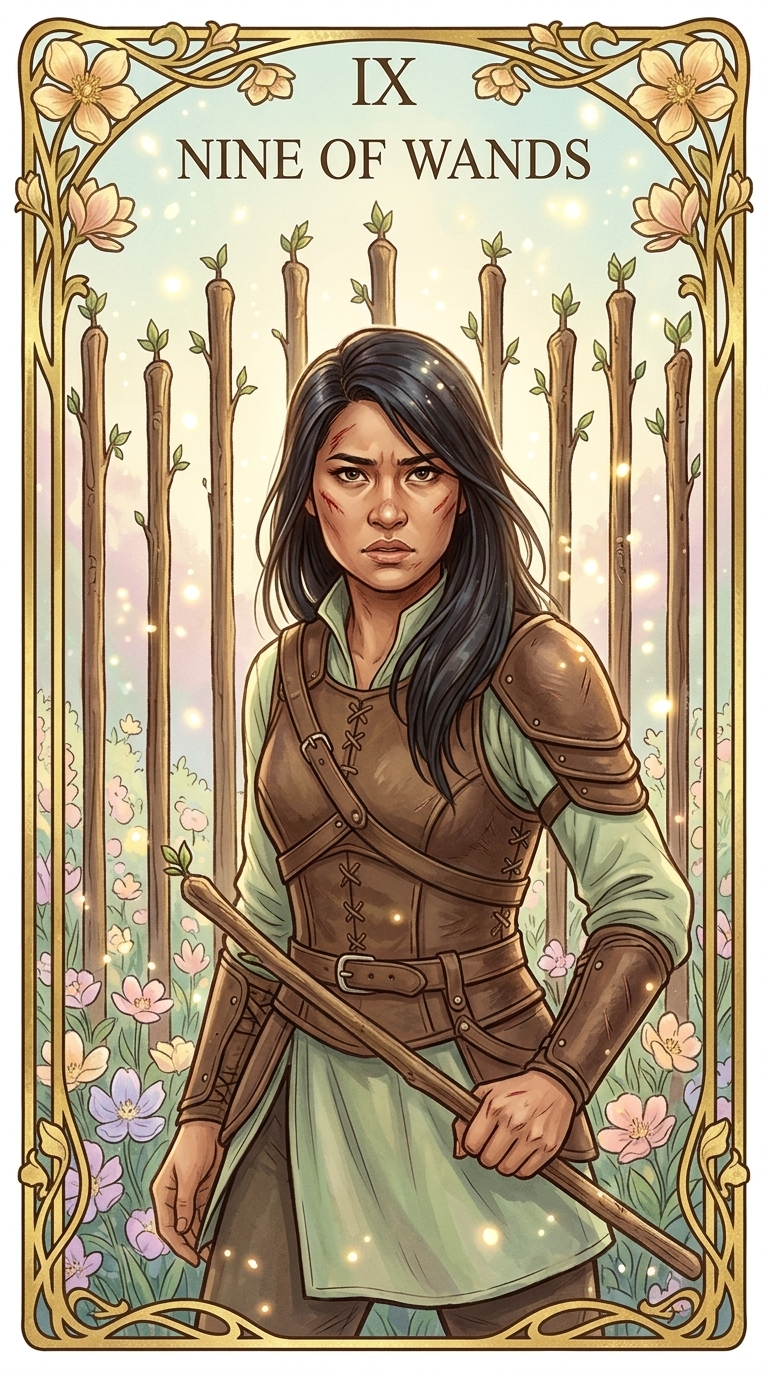

Counting: success
Detected wand count: 10 (expected 9)
Count feedback: There are 10 wands depicted in total: 9 upright wooden wands standing in the background field behind the figure, and 1 diagonal wand held across her body in her left hand.
Count matches expected: False

Attempt 2
Generation: success
Interaction ID: v1_ChdBTXV2YXQzV0c1ZlFqdU1QaVBtNS1BURIXQU11dmF0M1dHNWZRanVNUGlQbTUtQVE


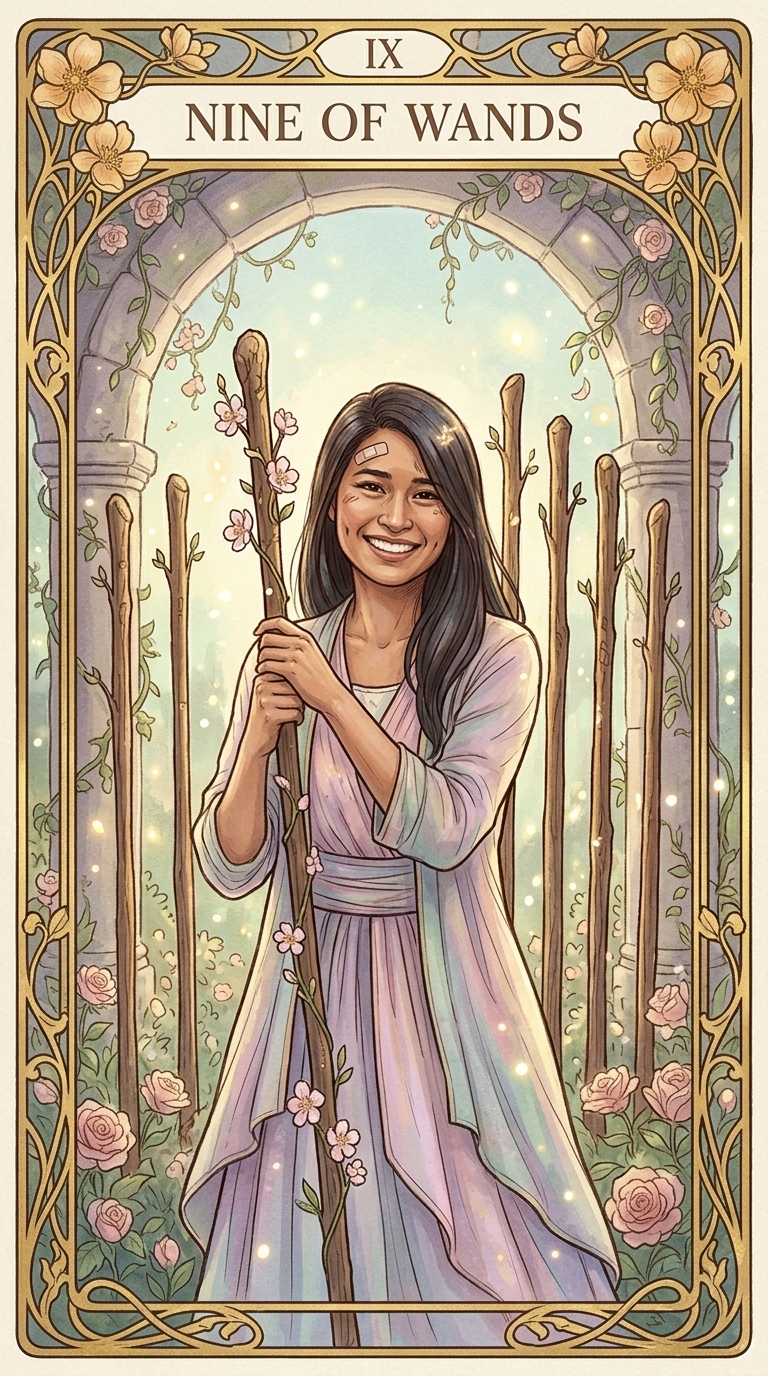

Counting: success
Detected wand count: 7 (expected 9)
Count feedback: I counted 7 physical wooden wands (staffs): 1 central wand held in the woman's hands, 2 upright wands standing in the background to her left, and 4 upright wands standing in the background to her right.
Count matches expected: False

Attempt 3
Generation: success
Interaction ID: v1_ChdHOHV2YXBESkNLM1JnOFVQcmRqb3lBTRIXRzh1dmFwREpDSzNSZzhVUHJkam95QU0


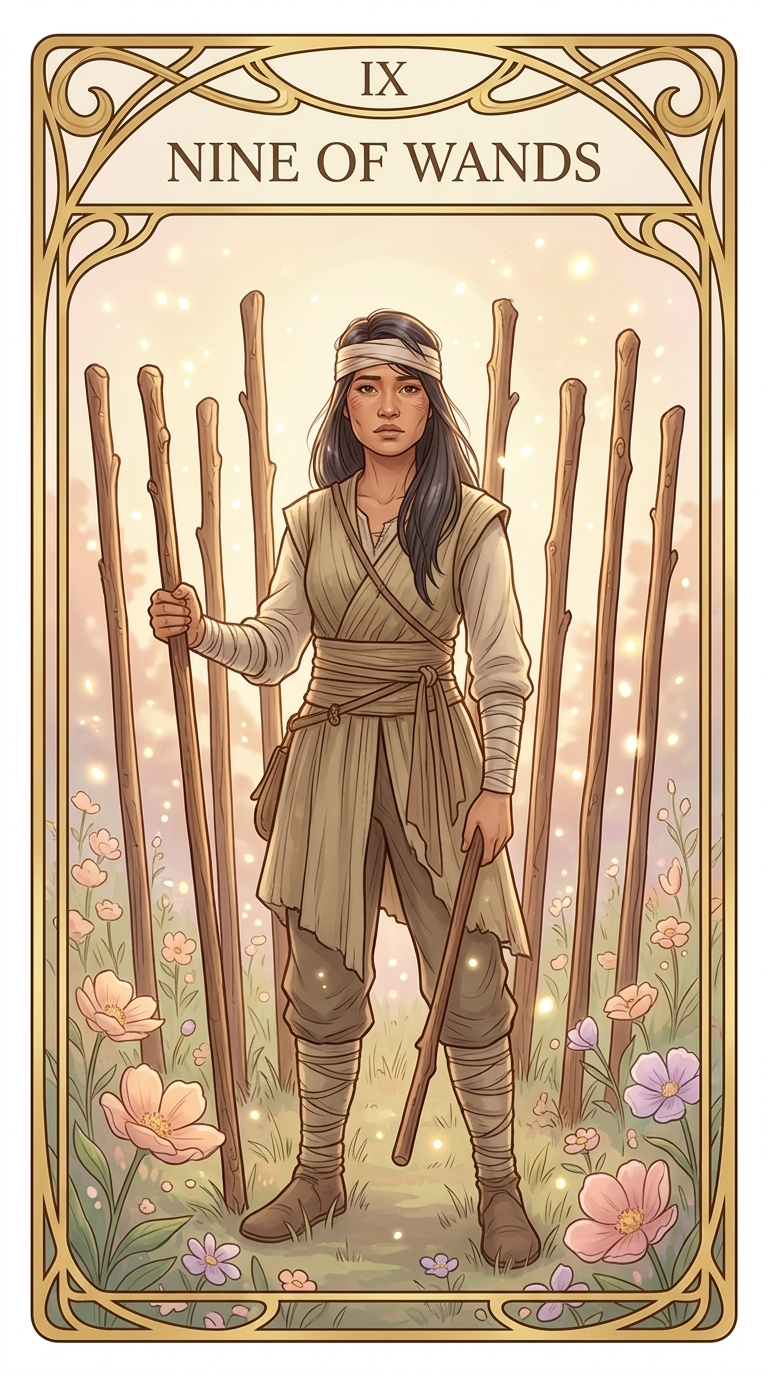

Counting: success
Detected wand count: 9 (expected 9)
Count feedback: There are 9 physical wands visible in the image: 8 vertical wooden wands planted upright in the ground behind the figure (4 to her right, including the one touched by her right hand, and 4 to her left), plus 1 shorter wand/staff held in her left hand pointing diagonally toward the ground.
Count matches expected: True

Final result: success
Generation attempts used: 3 / 3


In [57]:
for attempt in final_state["attempts"]:
    print(f"\n{'=' * 72}")
    print(f"Attempt {attempt['attempt_number']}")
    print(f"Generation: {attempt['generation_status']}")

    if attempt["generation_error"]:
        print(f"Generation error: {attempt['generation_error']}")
    else:
        print(f"Interaction ID: {attempt['generation_interaction_id']}")
        image_bytes = base64.b64decode(
            attempt["generated_image_data"], validate=True
        )
        display(DisplayImage(data=image_bytes, width=300))

    print(f"Counting: {attempt['count_status']}")
    if attempt["count_status"] == "success":
        print(
            f"Detected {expected_item_name} count: "
            f"{attempt['detected_item_count']} (expected {expected_item_count})"
        )
        print(f"Count feedback: {attempt['count_feedback']}")
        print(
            "Count matches expected: "
            f"{attempt['detected_item_count'] == expected_item_count}"
        )
    elif attempt["count_error"]:
        print(f"Count error: {attempt['count_error']}")

print(f"\n{'=' * 72}")
print(f"Final result: {final_state['result']}")
print(f"Generation attempts used: {final_state['current_attempt']} / {MAX_ATTEMPTS}")

# End

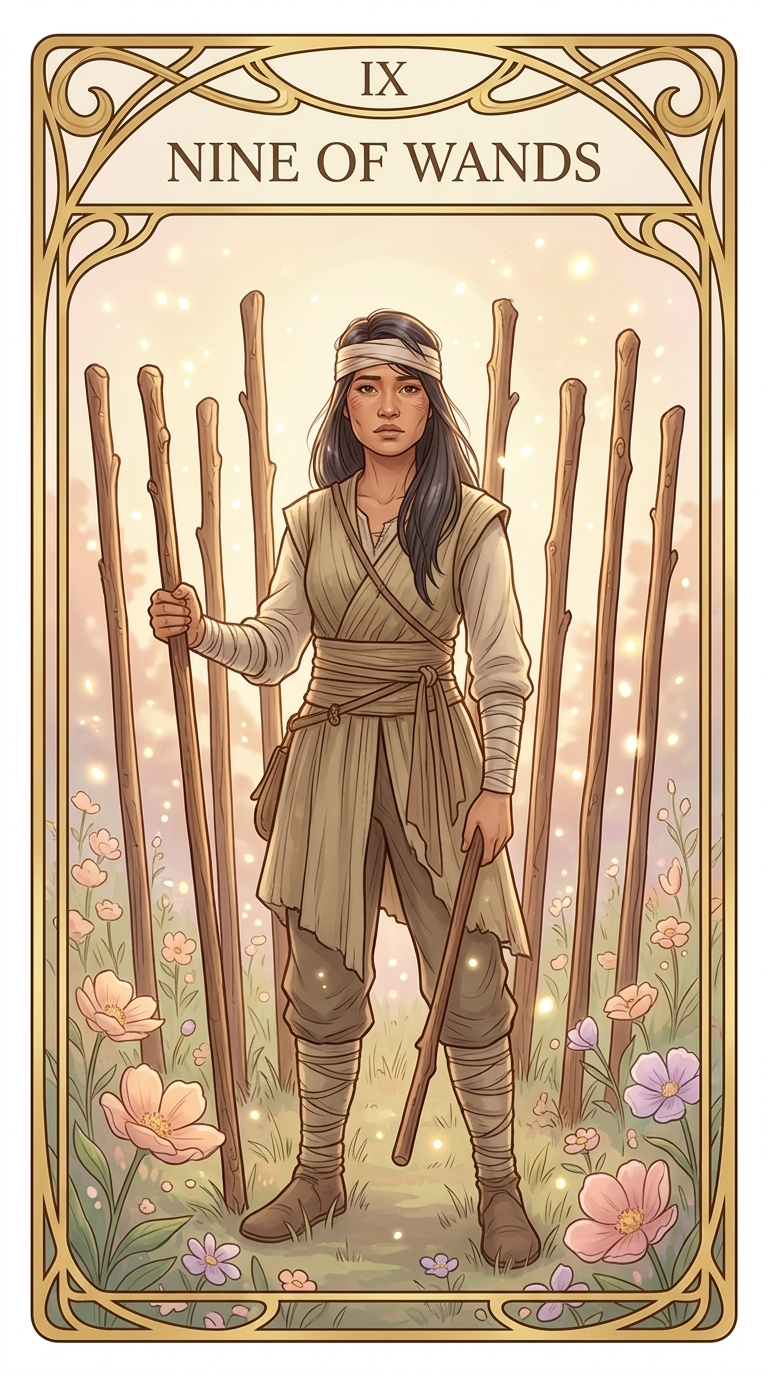

In [58]:
# display(DisplayImage(data=image_bytes))
# final_state["attempts"][-1]["generated_image_data"]
image_bytes = base64.b64decode(
  final_state["attempts"][-1]["generated_image_data"], validate=True
)
display(DisplayImage(data=image_bytes, width=300))